# Oasis Infobyte Internship

In [67]:
# Step 1 - Import Required Libraries
# Import Libraries

import pandas as pd
import numpy as np
import os
os.makedirs("Images", exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
## Why these libraries?
# Pandas is used for data manipulation.
# NumPy is used for numerical computations.
# Matplotlib is used for creating basic visualizations.
# Seaborn is used for statistical charts.

In [2]:
# Loading Dataset
df = pd.read_csv("Retail_Sales_Dataset.csv")

In [3]:
df.head()
#Dataset Inspection
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()
# The dataset contains 0 missing values.

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df.sample(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
445,446,2023-06-07,CUST446,Male,21,Electronics,1,50,50
642,643,2023-09-24,CUST643,Female,28,Electronics,3,30,90
896,897,2023-09-26,CUST897,Female,64,Electronics,2,50,100
740,741,2023-11-30,CUST741,Male,48,Clothing,1,300,300
820,821,2023-02-14,CUST821,Male,49,Electronics,1,300,300
880,881,2023-05-19,CUST881,Male,22,Electronics,1,300,300
548,549,2023-08-04,CUST549,Female,50,Beauty,2,50,100
913,914,2023-10-11,CUST914,Female,59,Electronics,1,500,500
408,409,2023-12-18,CUST409,Female,21,Electronics,3,300,900
968,969,2023-04-19,CUST969,Female,40,Clothing,3,300,900


Data Cleaning & Feature Engineering

In [11]:
# Check missing values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [12]:
# Check duplicate rows
df.duplicated().sum()
# There is no null and duplicated values

np.int64(0)

In [13]:
# Convert Date column

df["Date"] = pd.to_datetime(df["Date"])

In [14]:
# Verify datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [15]:
# Create Year column
df["Year"] = df["Date"].dt.year

In [16]:
# Create Month Name
df["Month"] = df["Date"].dt.month_name()


In [17]:
# Create Month Number
df["Month Number"] = df["Date"].dt.month

In [18]:
# Create Day Name
df["Day"] = df["Date"].dt.day_name()

In [19]:
# Create Quarter
df["Quarter"] = df["Date"].dt.quarter

In [20]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month Number,Day,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,November,11,Friday,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,February,2,Monday,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,January,1,Friday,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,May,5,Sunday,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,May,5,Saturday,2


- Several new time-based features have been created.
- These features will help analyze sales
- trends across different months,
- quarters, years, and weekdays.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Year              1000 non-null   int32         
 10  Month             1000 non-null   object        
 11  Month Number      1000 non-null   int32         
 12  Day               1000 non-null   object        
 13  Quarter           1000 non-null   int32         
dtypes: datetime64[ns](1), int

#### The dataset is now clean and ready
#### for Exploratory Data Analysis.

### Summary

 The following preprocessing steps were completed successfully:

 - Checked missing values
 - Checked duplicate records
 - Removed duplicate rows
 - Converted Date column into datetime format
 - Created Year, Month, Month Number, Quarter, and Day columns

 The dataset is now ready for detailed 
 statistical analysis and visualization

####  Select Numerical Columns

In [22]:
# Display numerical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"])

numerical_columns.head()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,34,3,50,150
1,2,26,2,500,1000
2,3,50,1,30,30
3,4,37,1,500,500
4,5,30,2,50,100


In [23]:
# Summary statistics
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year,Month Number,Quarter
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2023.002000,6.549000,2.525000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000,1.000000,1.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000,4.000000,2.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000,6.000000,2.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000,10.000000,4.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000,12.000000,4.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699,3.452755,1.119208


In [24]:
# Calculate Mean
df.mean(numeric_only=True)

Transaction ID     500.500
Age                 41.392
Quantity             2.514
Price per Unit     179.890
Total Amount       456.000
Year              2023.002
Month Number         6.549
Quarter              2.525
dtype: float64

#### Observation
- The mean represents the average value of each numerical variable.
- It provides an overall estimate of the central value of the data.

In [25]:
# Calculate Median
df.median(numeric_only=True)

Transaction ID     500.5
Age                 42.0
Quantity             3.0
Price per Unit      50.0
Total Amount       135.0
Year              2023.0
Month Number         6.0
Quarter              2.0
dtype: float64

In [26]:
# Calculate Mode
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Year,Month Number,Quarter
0,1,43.0,4.0,50.0,50.0,2023.0,5.0,2.0
1,2,64.0,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Calculate Standard Deviation
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
Year                0.044699
Month Number        3.452755
Quarter             1.119208
dtype: float64

In [28]:
# Minimum values
df.min(numeric_only=True)

Transaction ID       1
Age                 18
Quantity             1
Price per Unit      25
Total Amount        25
Year              2023
Month Number         1
Quarter              1
dtype: int64

In [29]:
# Maximum values
df.max(numeric_only=True)

Transaction ID    1000
Age                 64
Quantity             4
Price per Unit     500
Total Amount      2000
Year              2024
Month Number        12
Quarter              4
dtype: int64

 Observation
- The minimum and maximum values define 
- the range of each numerical variable.
- These values help identify possible extreme observations.

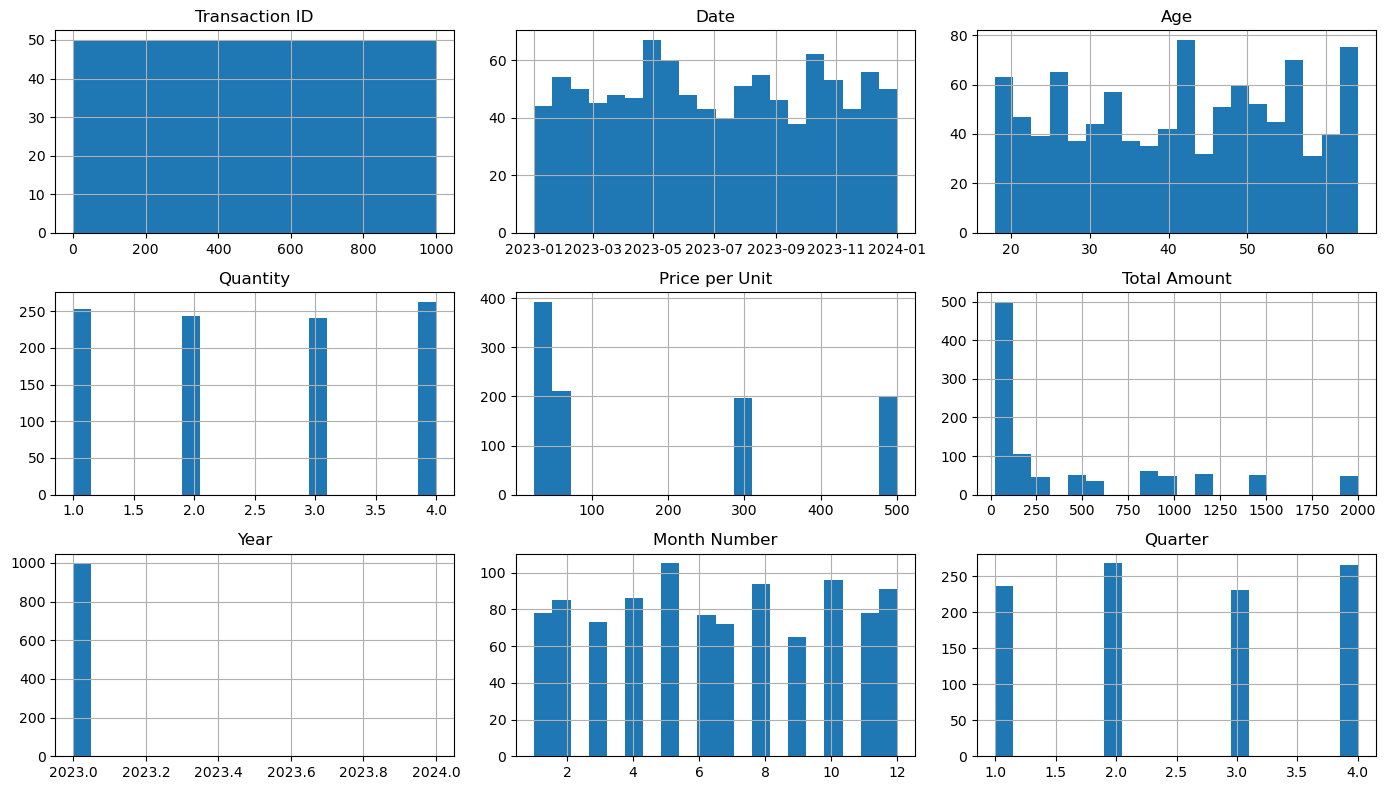

In [30]:
# Histograms for numerical columns
df.hist(figsize=(14,8), bins=20)
plt.tight_layout()
plt.show()

In [31]:
### Observation
# The histograms show the distribution of numerical variables.
# They help identify skewness, spread, 
# concentration of values, and potential outliers.

 Summary
 In this step, descriptive statistics were calculated for all numerical variables.
 The analysis included:
 - Mean
 - Median
 - Mode
 - Standard Deviation
 - Variance
 - Minimum and Maximum Values
 - Distribution using Histograms

### Time Series Analysis

- Monthly Sales Trend

In [32]:
# Calculate Monthly Sales

monthly_sales = (
    df.groupby(["Month Number", "Month"])["Total Amount"]
    .sum()
    .reset_index()
)

# Sort months in calendar order

monthly_sales = monthly_sales.sort_values("Month Number")

monthly_sales

,Month Number,Month,Total Amount
0,1,January,36980
1,2,February,44060
2,3,March,28990
3,4,April,33870
4,5,May,53150
5,6,June,36715
6,7,July,35465
7,8,August,36960
8,9,September,23620
9,10,October,46580


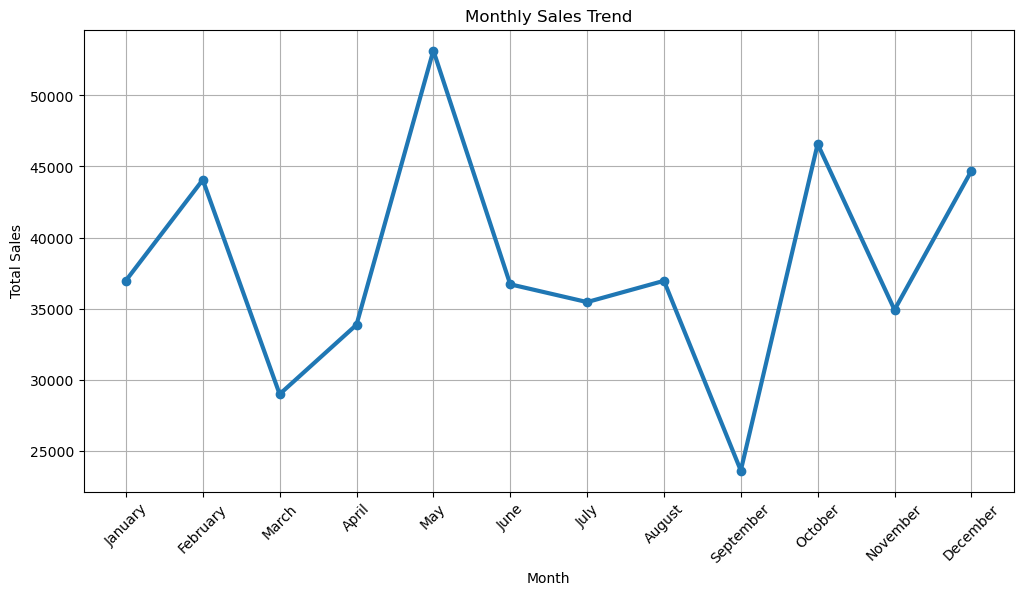

In [68]:
# Monthly Sales Line Chart

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Total Amount"],
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)
plt.savefig("Images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Quarterly Sales Trend

In [34]:
# Calculate Quarterly Sales

quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
    .sum()
    .reset_index()
)

quarterly_sales

,Quarter,Total Amount
0,1,110030
1,2,123735
2,3,96045
3,4,126190


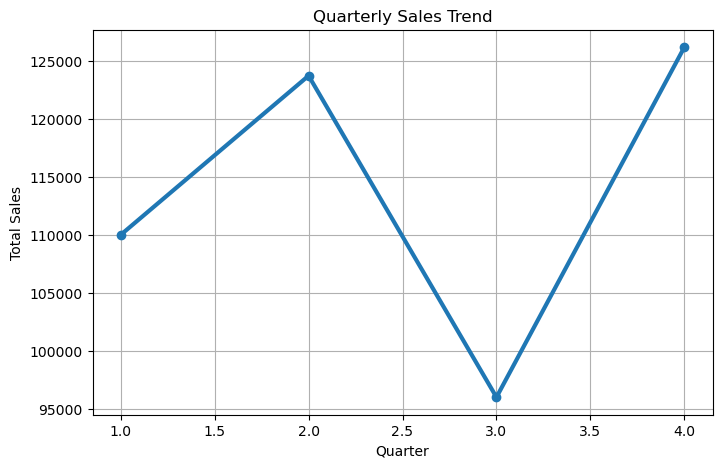

In [69]:
# Quarterly Sales Line Chart

plt.figure(figsize=(8,5))

plt.plot(
    quarterly_sales["Quarter"],
    quarterly_sales["Total Amount"],
    marker="o",
    linewidth=3
)

plt.title("Quarterly Sales Trend")

plt.xlabel("Quarter")

plt.ylabel("Total Sales")

plt.grid(True)
plt.savefig("Images/quarterly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Monthly Sales Summary

In [36]:
monthly_sales.sort_values(
    by="Total Amount",
    ascending=False
)

,Month Number,Month,Total Amount
4,5,May,53150
9,10,October,46580
11,12,December,44690
1,2,February,44060
0,1,January,36980
7,8,August,36960
5,6,June,36715
6,7,July,35465
10,11,November,34920
3,4,April,33870


## Summary

- Time-based analysis was performed
- using monthly and quarterly sales trends.
- The analysis provides valuable insights
- into seasonal demand and business 
- performance over different time periods

#  Customer Demographics Analysis

#### Age Distribution

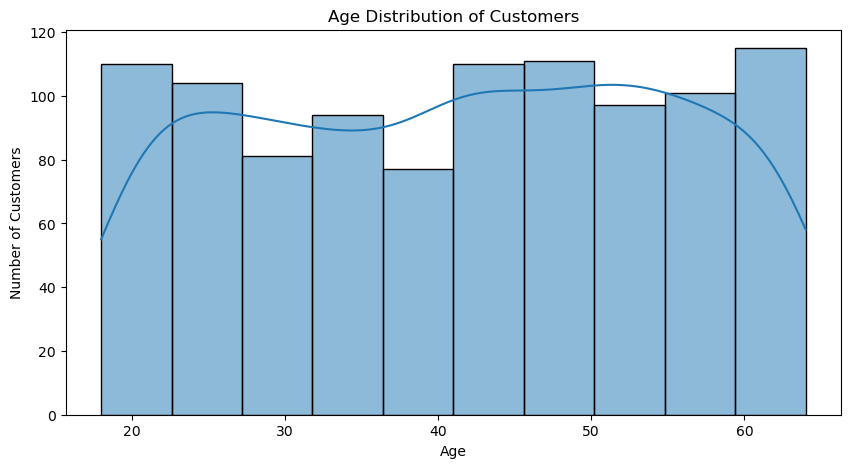

In [70]:
plt.figure(figsize=(10,5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution of Customers")

plt.xlabel("Age")

plt.ylabel("Number of Customers")
plt.savefig("Images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### Create Age Groups

In [42]:
bins = [0,18,25,35,45,60,100]

labels = [
    "0-18",
    "19-25",
    "26-35",
    "36-45",
    "46-60",
    "60+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [43]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month Number,Day,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,November,11,Friday,4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,February,2,Monday,1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,January,1,Friday,1,46-60
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,May,5,Sunday,2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,May,5,Saturday,2,26-35


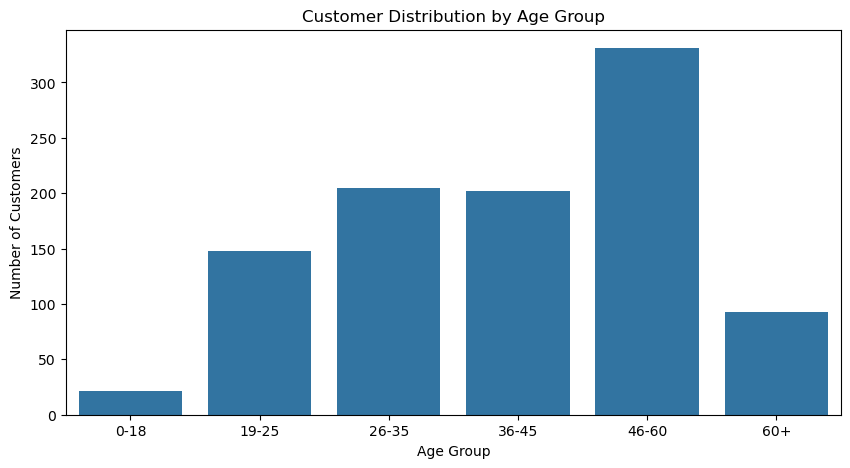

In [71]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Age Group",
    data=df,
    order=labels
)

plt.title("Customer Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Number of Customers")
plt.savefig("Images/customer_age_groups.png", dpi=300, bbox_inches="tight")
plt.show()

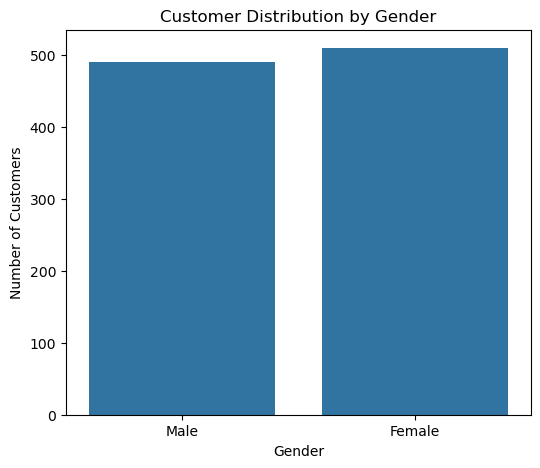

In [72]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Gender",
    data=df
)

plt.title("Customer Distribution by Gender")

plt.xlabel("Gender")

plt.ylabel("Number of Customers")
plt.savefig("Images/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
gender_sales = (
    df.groupby("Gender")["Total Amount"]
    .sum()
    .reset_index()
)

gender_sales

,Gender,Total Amount
0,Female,232840
1,Male,223160


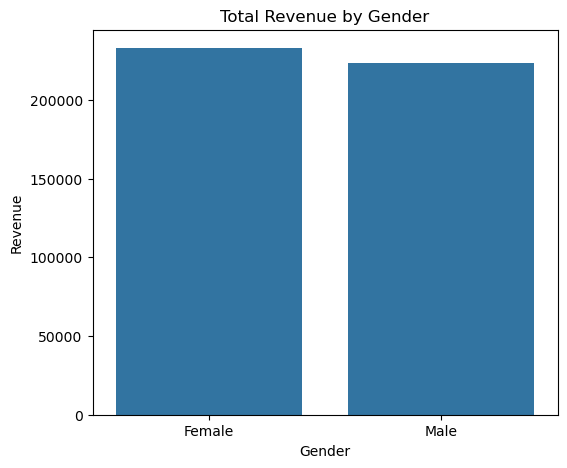

In [77]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="Gender",
    y="Total Amount",
    data=gender_sales
)

plt.title("Total Revenue by Gender")

plt.xlabel("Gender")

plt.ylabel("Revenue")
plt.show()

**Summary**

Customer demographics
were analyzed using age and gender information.

The analysis included:

- Age Distribution
- Customer Age Groups
- Gender Distribution
- Revenue by Gender

These insights help businesses
better understand their customers 
and design targeted marketing strategies.

####  Product Analysis

###### Top Product Categories

In [48]:
top_category = df.groupby("Product Category")["Quantity"]
                .sum().sort_values(ascending=False)

top_category

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

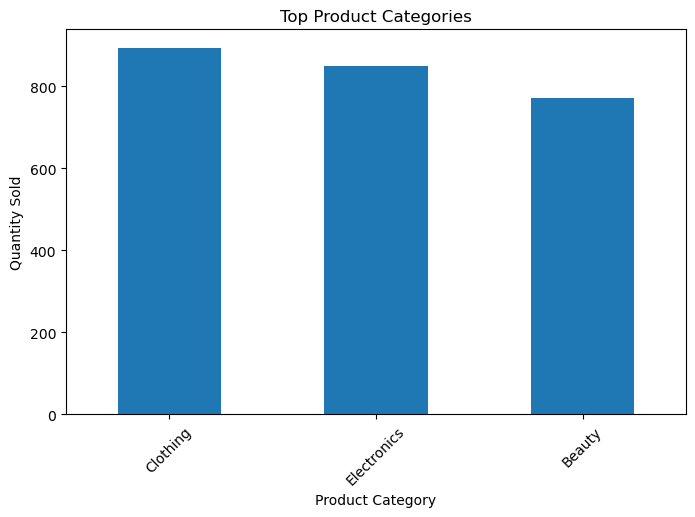

In [78]:
plt.figure(figsize=(8,5))

top_category.plot(kind="bar")

plt.title("Top Product Categories")

plt.xlabel("Product Category")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.savefig("Images/top_product_categories.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

#### Revenue by Product Category

In [61]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

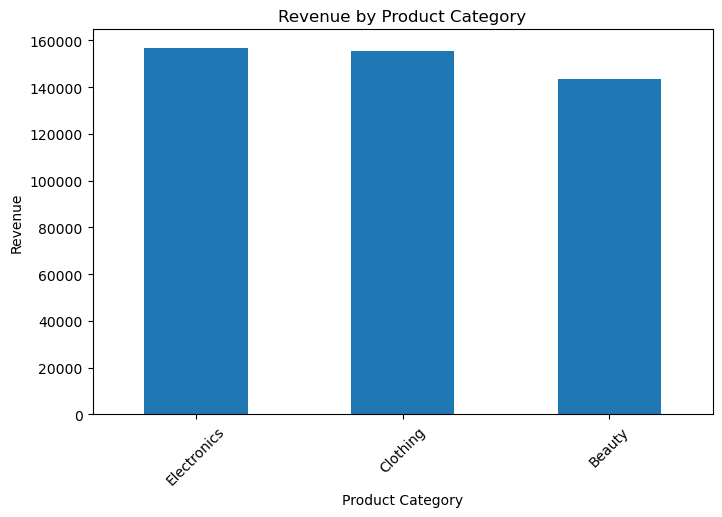

In [79]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.savefig("Images/revenue_by_product_category.png", dpi=300, bbox_inches="tight")
plt.show()

**Summary**
- Identified top-selling product categories.
- Analyzed revenue by product category.

#### Correlation Heatmap

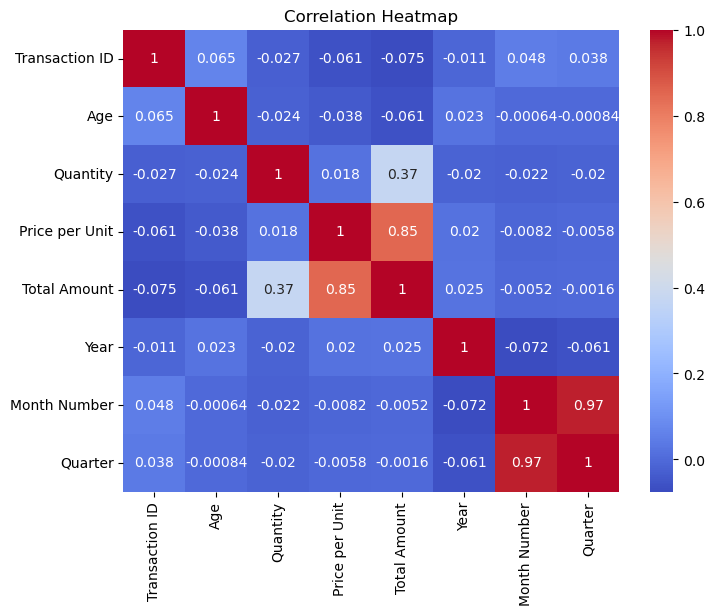

In [66]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

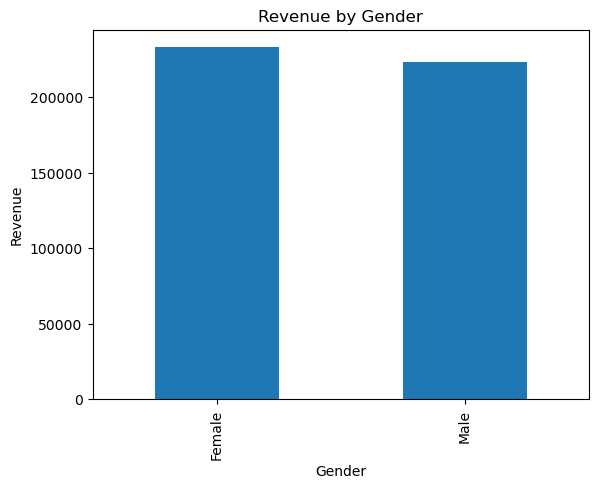

In [64]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales.plot(kind="bar")

plt.title("Revenue by Gender")

plt.xlabel("Gender")

plt.ylabel("Revenue")

plt.show()